# `Julia` ONRAMP
---

### GOALS
- Execute commands in ${\tt Julia}$ REPL to create variables and perform calculations;
- Write and save programs;
- Use indexing to extract and modify rows, columns, and elements of ${\tt Julia}$ tensors.

${\tt Julia}$ is a standalone program which can be downloaded from [https://julialang.org/downloads/](https://julialang.org/downloads/)

**Getting around**

By default, Julia runs in an interactive terminal called the REPL. In this mode, Some useful commands are:
1. `^C` aborts execution
1. `^D` exits Julia
1. `?` enters help mode
1. `;` enters system shell mode
1. `]` enters package manager mode
1. `^l` clears screen

We begin first by activating the environement within the desired folder.

From the REPL interface, either type:
```julia
using Pkg  
pkg"activate ."
```
or access the package mode by typing `]` and writing:
```julia
activate .
```
To see the full list of installed packages, always within the package mode, we type:
```julia
st
```

In [1]:
# Activate the Julia environment located one folder up
using Pkg; pkg"activate .."

  Activating project at `/workspace`


In [2]:
# List the packages installed in the active environment
using Pkg; pkg"status"

Status `/workspace/Project.toml`
⌃ [336ed68f] CSV v0.10.15
⌃ [a93c6f00] DataFrames v1.8.1
⌃ [587475ba] Flux v0.16.7
  [a9166f1b] Fuzzy v0.3.1
  [d8c32880] ImageInTerminal v0.5.4
⌃ [add582a8] MLJ v0.22.0
⌃ [91a5bcdd] Plots v1.41.4
⌃ [c3e4b0f8] Pluto v0.20.21
⌃ [7f904dfe] PlutoUI v0.7.77
  [92933f4c] ProgressMeter v1.11.0
  [d6f4376e] Markdown v1.11.0
Info Packages marked with ⌃ have new versions available and may be upgradable.


To add the **Markdown** package for instance, we write

In [3]:
# Add the Markdown package to the environment
using Pkg; pkg"add Markdown"

   Resolving package versions...
  No Changes to `/workspace/Project.toml`
  No Changes to `/workspace/Manifest.toml`


To be able to use it, we do as follows

In [4]:
# Load the Markdown package
using Markdown

In [5]:
# `md"""..."""` renders Markdown-formatted text as a code cell's output
md"""
This a text inside a code cell, thanks to **Markdown** package. I can _emphasize_ anything. Make other things **bold**
"""

This a text inside a code cell, thanks to **Markdown** package. I can *emphasize* anything. Make other things **bold**


`Jupyter Lab` is pretty handy. We only need to install the appropriate kernel. In order to add `Julia` kernel `IJulia` to Jupyter Notebook and/or `JupyterLab` IDEs, we begin by executing the following commands:
```julia
using Pkg  
Pkg.add("IJulia") 
```
If we want to get `JupyterLab` instance running in current directory, we can do:
```julia
jupyterlab(dir=pwd(), detached=true)
```

In case things do not work, we run the two following commands from ${\tt Julia}$ REPL which launch jupyter environment.
```julia
using IJulia  
installkernel("Julia") 
```

The shell mode is also available through the REPL to evaluate some OS commands. To do so, simply preface the regular command by a semicolon. For instance, `pwd` prints the path to the working directory, and `ls` allows listing the content of the current directory.

In [6]:
# Shell mode (prefixed with `;`): print the current working directory
;pwd

/workspace/Jupyter


In [7]:
# Shell mode: list the contents of the current directory
;ls -la

total 3144
drwxr-xr-x 1 root root    4096 Sep 14 20:08 .
drwxr-xr-x 1 root root    4096 Jan  8  2026 ..
drwxr-xr-x 2 root root    4096 Sep 14 20:04 .ipynb_checkpoints
-rw-r--r-- 1 root root     185 Jan  8  2026 README.md
-rw-r--r-- 1 root root   18410 Sep 14 20:06 backward_chaining.ipynb
-rw-r--r-- 1 root root  498971 Sep 14 20:07 classifier-ann.ipynb
-rw-r--r-- 1 root root   14188 Sep 14 20:06 forward_chaining.ipynb
-rw-r--r-- 1 root root   40435 Sep 14 20:08 julia-onramp.ipynb
-rw-r--r-- 1 root root   11002 Jan  8  2026 jupyter.svg
-rw-r--r-- 1 root root   10913 Sep 14 20:08 selection-process.ipynb
-rw-r--r-- 1 root root  270756 Sep 14 19:50 tipper.ipynb
-rw-r--r-- 1 root root 2318214 Sep 14 20:07 xor-gate.ipynb


### Getting Help

In order to seek help on a particular function. We just use the `?` mark. We can use the ${\tt Julia}$ documentation to discover more pieces of information about ${\tt Julia}$ features.

In [8]:
# Help mode (prefixed with `?`): show documentation for `cos`
?cos

search: cos cosc acos cosh cosd cis cot acosh const acosd cospi close sincos



```
cos(x)
```

Compute cosine of `x`, where `x` is in radians.

See also [`cosd`](@ref), [`cospi`](@ref), [`sincos`](@ref), [`cis`](@ref).

---

```
cos(A::AbstractMatrix)
```

Compute the matrix cosine of a square matrix `A`.

If `A` is symmetric or Hermitian, its eigendecomposition ([`eigen`](@ref)) is used to compute the cosine. Otherwise, the cosine is determined by calling [`exp`](@ref).

# Examples

```jldoctest
julia> cos(fill(1.0, (2,2)))
2×2 Matrix{Float64}:
  0.291927  -0.708073
 -0.708073   0.291927
```


To print something to the standard output, it is possible to use either `print` or `println`. The last one displays the text and moves the cursor to the next line.

In [9]:
# `print` does NOT add a trailing newline after each call
print("Hello")
print(' ')
print("World")

Hello World

In [10]:
# `println` adds a newline after each call
println("Hello")
println("World")

Hello
World


**Data types: Dictionaries**

In [11]:
# Dictionary mapping vehicle name -> number of wheels
dict = Dict(
    # Name => # of wheels
    "Unicycle" => 1,
    "Bicycle" => 2,
    "Tricycle" => 3
)

Dict{String, Int64} with 3 entries:
  "Bicycle"  => 2
  "Tricycle" => 3
  "Unicycle" => 1

In [12]:
# Check the type of `dict`
typeof(dict)

Dict{String, Int64}

In [13]:
# Equivalent way to build the same dictionary, from a vector of (key, value) pairs
dict = Dict([("Unicycle", 1), ("Bicycle", 2), ("Tricycle", 3)])

Dict{String, Int64} with 3 entries:
  "Bicycle"  => 2
  "Tricycle" => 3
  "Unicycle" => 1

In [14]:
# Access a value by its key
dict["Bicycle"]

2

In [15]:
# A `Vector{Any}` can freely mix different types
vect = [1, 'a', "abc", true, [0, .5im]]

5-element Vector{Any}:
    1
     'a': ASCII/Unicode U+0061 (category Ll: Letter, lowercase)
     "abc"
 true
     ComplexF64[0.0 + 0.0im, 0.0 + 0.5im]

In [16]:
# Check the type of `vect`
typeof(vect)

Vector{Any} (alias for Array{Any, 1})

In [17]:
# `end` refers to the last valid index of the array
vect[end]

2-element Vector{ComplexF64}:
 0.0 + 0.0im
 0.0 + 0.5im

### Basic Calculations

In [18]:
# Multiple assignment: `a` becomes an Int, `b` becomes a Float64
a, b = 1, 1.5

(1, 1.5)

In [19]:
# Print the inferred types of `a` and `b`
println(typeof(a))
println(typeof(b))

Int64
Float64


In [20]:
md"""
`varinfo` method allows to display loaded variables.
"""

`varinfo` method allows to display loaded variables.


In [21]:
# List all variables currently defined in this session
varinfo()

| name |      size | summary                            |
|:---- | ---------:|:---------------------------------- |
| Base |           | Module                             |
| Core |           | Module                             |
| Main |           | Module                             |
| a    |   8 bytes | Int64                              |
| b    |   8 bytes | Float64                            |
| dict | 431 bytes | Dict{String, Int64} with 3 entries |
| docs | 6.476 KiB | Markdown.MD                        |
| vect | 176 bytes | 5-element Vector{Any}              |


In [22]:
# Help mode: show documentation for `varinfo`
?varinfo

search: varinfo @info versioninfo



```
varinfo(m::Module=Main, pattern::Regex=r""; all=false, imported=false, recursive=false, sortby::Symbol=:name, minsize::Int=0)
```

Return a markdown table giving information about public global variables in a module, optionally restricted to those matching `pattern`.

The memory consumption estimate is an approximate lower bound on the size of the internal structure of the object.

  * `all` : also list non-public objects defined in the module, deprecated objects, and compiler-generated objects.
  * `imported` : also list objects explicitly imported from other modules.
  * `recursive` : recursively include objects in sub-modules, observing the same settings in each.
  * `sortby` : the column to sort results by. Options are `:name` (default), `:size`, and `:summary`.
  * `minsize` : only includes objects with size at least `minsize` bytes. Defaults to `0`.

The output of `varinfo` is intended for display purposes only.  See also [`names`](@ref) to get an array of symbols defined in a module, which is suitable for more general manipulations.


In [23]:
# String interpolation: `$var` and `$(expr)` embed values inside a string
println("Sum of $a and $b is $(a+b)")

Sum of 1 and 1.5 is 2.5


Addition, subtraction, multiplication, division, exponent

In [24]:
# Arithmetic operators: +, -, *, ÷ (integer division), ^ (power)
a+b, a-b, a*b, a÷b, a^b

(2.5, -0.5, 1.5, 0.0, 1.0)

In [25]:
md"""
**Unicode support** 
1. We can use π instead of `pi`
1. Greek letters improe comprehension: α _(alpha)_, β _(beta)_, ...
1. Symbols: ≥ _(>=)_, ≤ _(<=)_, ∈ _(in)_, ... 
1. ...
"""

**Unicode support** 

1. We can use π instead of `pi`
2. Greek letters improe comprehension: α *(alpha)*, β *(beta)*, ...
3. Symbols: ≥ *(>=)*, ≤ *(<=)*, ∈ *(in)*, ...
4. ...


In [26]:
# Comparison works directly with the built-in π constant
3 ≤ π 

true

In [27]:
# Check the type of a floating-point literal
typeof(3.14)

Float64

In [28]:
# Walk up the type hierarchy starting from Float64
Float64 |> supertype |> supertype |> supertype |> supertype 

Any

In [29]:
# List all subtypes of `Integer`
Integer |> subtypes

3-element Vector{Any}:
 Bool
 Signed
 Unsigned

In [30]:
# List all subtypes of `Signed`
Signed |> subtypes

6-element Vector{Any}:
 BigInt
 Int128
 Int16
 Int32
 Int64
 Int8

In [31]:
UInt8 <: Unsigned  # UInt8 is one subtype of Unsigned

true

In [32]:
Signed >: Int8  # Signed is supertype of Int8

true

In [33]:
# Check the type of an integer literal (default: Int64)
typeof(3)

Int64

In [34]:
# Type annotation forces `tmp` to be stored as UInt8
tmp::UInt8 = 3
typeof(tmp)

UInt8

### Mathematical Notation

In [35]:
# `+` can be used either as an infix operator or as a regular function call
println(1+2)
println(+(1, 2))

3
3


In [36]:
# Same thing with subtraction
println(1-2)
println(-(1, 2))

-1
-1


In [37]:
# Same thing with multiplication
println(1*2)
println(*(1, 2))

2
2


In [38]:
# Same thing with division
println(1/2)
println(/(1, 2))

0.5
0.5


In [39]:
# `//` builds an exact Rational number instead of a Float64 approximation
println(3/4+7/5)
println(3//4+7//5)

2.15
43//20


### Array Transformations

Perform calculations on entire arrays at once.

In [40]:
# 3x2 matrix of zeros
zeros(3, 2)

3×2 Matrix{Float64}:
 0.0  0.0
 0.0  0.0
 0.0  0.0

In [41]:
# 3x3x2 array of ones (3-dimensional)
ones(3, 3, 2)

3×3×2 Array{Float64, 3}:
[:, :, 1] =
 1.0  1.0  1.0
 1.0  1.0  1.0
 1.0  1.0  1.0

[:, :, 2] =
 1.0  1.0  1.0
 1.0  1.0  1.0
 1.0  1.0  1.0

In [42]:
# 2x2 matrix filled with the value π
fill(π, (2, 2))

2×2 Matrix{Irrational{:π}}:
 π  π
 π  π

In [43]:
# Broadcasting (`.*`) multiplies every element of the matrix by π
π .* ones(2, 2)

2×2 Matrix{Float64}:
 3.14159  3.14159
 3.14159  3.14159

In [44]:
md"Creates a `BitArray` with all values set to `true`"

Creates a `BitArray` with all values set to `true`


In [45]:
# 2x4 BitMatrix with every entry set to true
var = trues(2, 4)
println(var)
typeof(var)

Bool[1 1 1 1; 1 1 1 1]


BitMatrix (alias for BitArray{2})

In [46]:
md"Creates a `BitArray` with all values set to `false`"

Creates a `BitArray` with all values set to `false`


In [47]:
# 2x4 BitMatrix with every entry set to false
var = falses(2, 4)
println(var)
typeof(var)

Bool[0 0 0 0; 0 0 0 0]


BitMatrix (alias for BitArray{2})

In [48]:
md"**Comprehension**"

**Comprehension**


In [49]:
# Array comprehension: prints each character of the string
str = "Hello Julia"
[println(el) for el in str];

H
e
l
l
o
 
J
u
l
i
a


### Calling Functions

Call functions to obtain multiple outputs.

In [50]:
md"""
[Functions in ${\tt Julia}$](https://docs.julialang.org/en/v1/manual/functions/)
"""

[Functions in ${\tt Julia}$](https://docs.julialang.org/en/v1/manual/functions/)


In [51]:
md"**Spreading Arguments**"

**Spreading Arguments**


_Optional positional arguments_

In [52]:
# Optional positional arguments, each with a default value
foo(x=0, y=0, z=0) = x+y+z

foo (generic function with 4 methods)

In [53]:
# Call with all defaults, then with all arguments supplied
foo(), foo(1, 2, 3)

(0, 6)

In [54]:
foo([1, 2, 3]...) # Splat `...` operator

6

_Keywords arguments_

In [55]:
# Keyword arguments (after `;`), each typed and defaulted
bar(; a::Real=0, b::Real=0, c::Real=0) = a+b+c

bar (generic function with 1 method)

In [56]:
# Call using all keyword defaults
bar()

0

In [57]:
bar(; Dict(:a => 3, :b => 5.4, :c => -1.2)... ) # ; kwargs...

7.2

In [58]:
# THROWS AN ERROR 
try bar([1, 2, 3]...)
catch error
    println(error)
end

MethodError(Main.bar, (1, 2, 3), 0x0000000000006863)


In [59]:
md"**Multiple Dispatch**"

**Multiple Dispatch**


In [60]:
# 1st method signature
function f(x::Int)
    x^2
end

f (generic function with 1 method)

In [61]:
# 2nd method signature
f(x::Float64) = x^2+1

f (generic function with 2 methods)

In [62]:
# 3rd method signature
f(x::Char) = x*'y'*'z'

f (generic function with 3 methods)

In [63]:
# 4th mehod signature
f(x::String) = x*x 

f (generic function with 4 methods)

In [64]:
# List every method signature currently defined for `f`
methods(f)

# 4 methods for generic function "f" from Main:
 [1] f(x::String)
     @ In[63]:2
 [2] f(x::Char)
     @ In[62]:2
 [3] f(x::Float64)
     @ In[61]:2
 [4] f(x::Int64)
     @ In[60]:2

In [65]:
# Julia picks the matching method based on argument type (multiple dispatch)
f(1), f(1.), f('x'), f("abc")

(1, 2.0, "xyz", "abcabc")

In [66]:
mycos(x) = cos(x)
mycos(adj, hyp) = adj/hyp  # Extension to `mycos` function

mycos (generic function with 2 methods)

In [67]:
# List the two methods now defined for `mycos`
methods(mycos)

# 2 methods for generic function "mycos" from Main:
 [1] mycos(adj, hyp)
     @ In[66]:2
 [2] mycos(x)
     @ In[66]:1

In [68]:
# Show which method definition actually gets invoked for this call
@which mycos(π)

mycos(x)
     @ Main In[66]:1

In [69]:
# Show which method matches when called with two arguments
@which mycos(5, 3)

mycos(adj, hyp)
     @ Main In[66]:2

In [70]:
# Redefine `mycos` with a default value for `hyp`
mycos(adj, hyp=10) = adj/hyp

mycos (generic function with 2 methods)

In [71]:
# After the redefinition, check again which method resolves
@which mycos(π)

mycos(adj)
     @ Main In[70]:2

**Function Chaining** applies a function to the preceding argument.

In [72]:
# `|>` pipes the result of the left-hand side into the next function
g(x) = x+1
h(x) = x^2
x = 2 |> g |> h

9

In [73]:
md"Another pssible way is t use `∘` `\circ{tab}` symbol"

Another pssible way is t use `∘` `\circ{tab}` symbol


In [74]:
# `∘` composes functions: (h∘g)(x) is h(g(x))
(h∘g)(2)

9

In [75]:
md"Definition of a function can be done on the fly"

Definition of a function can be done on the fly


In [76]:
# Anonymous function `x->x^2` defined inline and piped through
y = 5 |> (x->x^2) |> √

5.0

In [77]:
md"""
**Metaprogramming:** Code is optimized by default in ${\tt Julia}$
"""

**Metaprogramming:** Code is optimized by default in ${\tt Julia}$


In [78]:
# Compute a running sum of squares from 1 to 100, added to `x`
function Foo(x::Integer)
    y = x
    for i=1:100
        y += i^2
    end
    return y
end

Foo (generic function with 1 method)

In [79]:
# Show the LLVM intermediate representation generated for `Foo(3)`
@code_llvm Foo(3)

; Function Signature: Foo(Int64)
;  @ In[78]:2 within `Foo`
define i64 @julia_Foo_14392(i64 signext %"x::Int64") #0 {
top:
  %0 = add i64 %"x::Int64", 338350
;  @ In[78]:7 within `Foo`
  ret i64 %0
}


In [80]:
# Help mode: show documentation for the `@code_llvm` macro
?@code_llvm

```
@code_llvm
```

Evaluates the arguments to the function or macro call, determines their types, and calls [`code_llvm`](@ref) on the resulting expression. Set the optional keyword arguments `raw`, `dump_module`, `debuginfo`, `optimize` by putting them and their value before the function call, like this:

```
@code_llvm raw=true dump_module=true debuginfo=:default f(x)
@code_llvm optimize=false f(x)
```

`optimize` controls whether additional optimizations, such as inlining, are also applied. `raw` makes all metadata and dbg.* calls visible. `debuginfo` may be one of `:source` (default) or `:none`,  to specify the verbosity of code comments. `dump_module` prints the entire module that encapsulates the function.

See also: [`code_llvm`](@ref), [`@code_warntype`](@ref), [`@code_typed`](@ref), [`@code_lowered`](@ref), [`@code_native`](@ref).


### Plotting Data

Visualize variables using ${\tt Julia}$'s plotting functions.

In [81]:
# Package mode (prefixed with `]`): add the Plots package
]add Plots

   Resolving package versions...
  No Changes to `/workspace/Project.toml`
  No Changes to `/workspace/Manifest.toml`


In [82]:
using Plots  # GR is the default backend

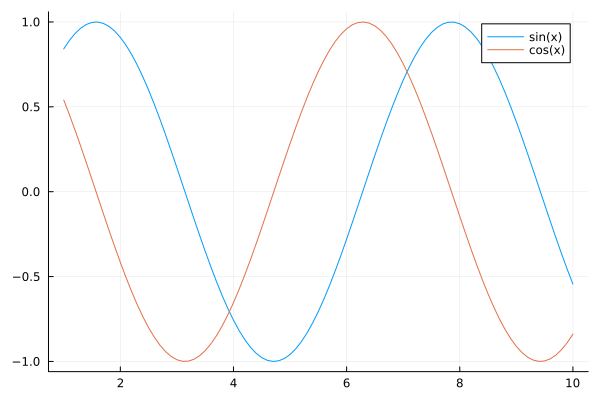

In [83]:
# Plot sin(x), then overlay cos(x) on the same axes with `plot!`
x = 1:.1:10
y = sin.(x)
z = cos.(x)

plot(x, y, label="sin(x)")
plot!(x, z, label="cos(x)")  # Holds on the previous plot

In [84]:
md"**Scatter Plot**"

**Scatter Plot**


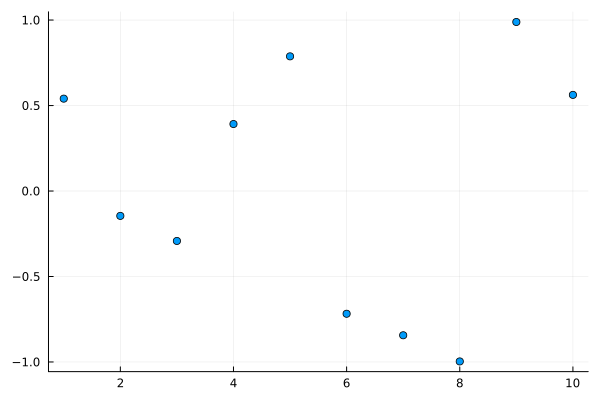

In [85]:
# Scatter plot of cos(x^3) against x
x = range(1, 10)
y = cos.(x.^3)
scatter(x, y, legend=false)

In [86]:
md"**Uniform Distribtion**"

**Uniform Distribtion**


In [87]:
# Help mode: show documentation for `rand`
?rand;

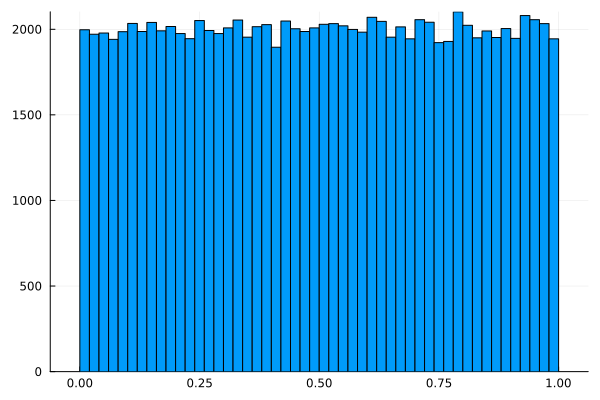

In [88]:
# Histogram of 100_000 uniformly distributed random numbers
x = rand(10^5)
histogram(x, bins=64, legend=false)

In [89]:
md"**Normal Distribution**"

**Normal Distribution**


In [90]:
# Help mode: show documentation for `randn`
?randn;

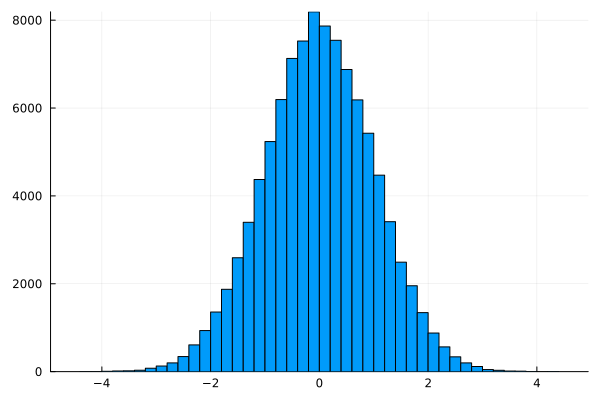

In [91]:
# Histogram of 100,000 normally distributed random numbers
x = randn(10^5)
histogram(x, bins=64, legend=false)

In [92]:
md"**Histogram in 2D**"

**Histogram in 2D**


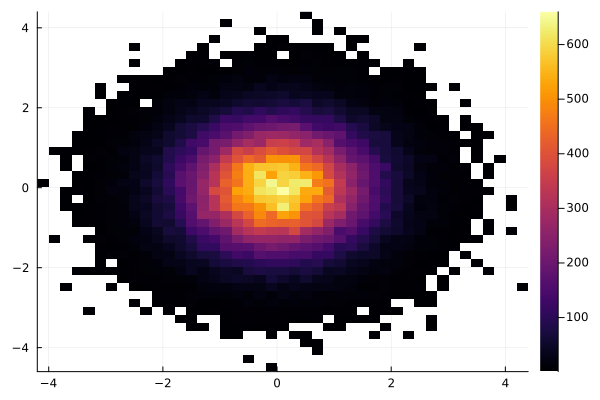

In [93]:
# 2D histogram (point density) built from two random samples
x = randn(10^5)
y = randn(10^5)
histogram2d(x, y, bins=(64, 64))

### Importing Data

Data is typically stored in files, such as _CSV_ or _JSON_ files, etc. In order to train and test machine learning models, the data needs to be loaded into the program. Additionally, the results of the training and testing process, such as model weights and performance metrics, also need to be saved to files. Therefore, the ability to manipulate files is essential for loading and saving data and model information in the machine learning process.

In [94]:
# Add the DataFrames and CSV packages
using Pkg
Pkg.add("DataFrames")
Pkg.add("CSV")

   Resolving package versions...
  No Changes to `/workspace/Project.toml`
  No Changes to `/workspace/Manifest.toml`
   Resolving package versions...
  No Changes to `/workspace/Project.toml`
  No Changes to `/workspace/Manifest.toml`


In [95]:
md"Create new CSV file"

Create new CSV file


In [96]:
# Load the CSV and DataFrames packages
using CSV, DataFrames

In [97]:
md"`touch` command allows to create a file if it doesn't exist. Otherwise, it changes the file timestamps."

`touch` command allows to create a file if it doesn't exist. Otherwise, it changes the file timestamps.


In [98]:
# Create an empty file (or update its timestamp if it already exists)
touch("aFile.csv")

"aFile.csv"

In [99]:
# Shell mode: confirm the file was created
;ls -la aFile.csv

-rw-r--r-- 1 root root 0 Sep 14 20:09 aFile.csv


To write data, open the file in write mode ("w")

In [100]:
# Open the file for writing
file = open("aFile.csv", "w")

IOStream(<file aFile.csv>)

In [101]:
write(file, "Hello, Julia")

12

Closing the file stream once the block finishes is mandatory, ensuring data integrity and resource release.

In [102]:
close(file)

In [103]:
md"Let's create some imaginary data"

Let's create some imaginary data


In [104]:
# Build a small DataFrame with student names, ids and marks
df = DataFrame(
        Student = ["Mohamed", "Sana", "Rami", "Ala"],
        Id = [1, 2, 3, 4],
        Marks = [18, 17, 12, 5.5]
        )

Row,Student,Id,Marks
,String,Int64,Float64
1,Mohamed,1,18.0
2,Sana,2,17.0
3,Rami,3,12.0
4,Ala,4,5.5


In [105]:
md"Write `df` to file"

Write `df` to file


In [106]:
# Write the DataFrame to the CSV file
CSV.write("aFile.csv", df)

"aFile.csv"

In [107]:
md"Open the CSV file and add some contents. See what happens when we load it again."

Open the CSV file and add some contents. See what happens when we load it again.


In [108]:
# Read the CSV file back into a DataFrame
CSV.read("aFile.csv", DataFrame)

Row,Student,Id,Marks
,String7,Int64,Float64
1,Mohamed,1,18.0
2,Sana,2,17.0
3,Rami,3,12.0
4,Ala,4,5.5


### Logical Arrays

Use logical expressions to help extract elements of interest from ${\tt Julia}$ arrays.

In [109]:
# A Vector{Complex} can hold ints, floats and complex numbers together
x = [1, 2, -5, 7.2, 3im]
println(x)
typeof(x)

ComplexF64[1.0 + 0.0im, 2.0 + 0.0im, -5.0 + 0.0im, 7.2 + 0.0im, 0.0 + 3.0im]


Vector{ComplexF64} (alias for Array{Complex{Float64}, 1})

In [110]:
# Boolean indexing: keep only the elements where `idx` is true
idx = [false, true, false, false, true]
print(x[idx])

ComplexF64[2.0 + 0.0im, 0.0 + 3.0im]

In [111]:
# Uninitialized 5x4 Float64 matrix (contents are garbage until set)
M = Array{Float64, 2}(undef, 5, 4)

5×4 Matrix{Float64}:
 5.0e-324      6.33787e-310  2.5e-323      6.33787e-310
 6.33787e-310  2.0e-323      6.33787e-310  2.0e-323
 1.0e-323      6.33787e-310  2.5e-323      6.33787e-310
 6.33787e-310  2.0e-323      6.33787e-310  1.0e-323
 1.5e-323      6.33787e-310  2.5e-323      6.33787e-310

In [112]:
# Boolean masks selecting which rows / columns to keep
row_idx = [true, false, true, true, false];
col_idx = [false, true, true, false];

In [113]:
# Select rows where `row_idx` is true, all columns
M[row_idx, :]

3×4 Matrix{Float64}:
 5.0e-324      6.33787e-310  2.5e-323      6.33787e-310
 1.0e-323      6.33787e-310  2.5e-323      6.33787e-310
 6.33787e-310  2.0e-323      6.33787e-310  1.0e-323

In [114]:
# Select all rows, columns where `col_idx` is true
M[:, col_idx]

5×2 Matrix{Float64}:
 6.33787e-310  2.5e-323
 2.0e-323      6.33787e-310
 6.33787e-310  2.5e-323
 2.0e-323      6.33787e-310
 6.33787e-310  2.5e-323

In [115]:
# Select rows and columns simultaneously using both masks
M[row_idx, col_idx]

3×2 Matrix{Float64}:
 6.33787e-310  2.5e-323
 6.33787e-310  2.5e-323
 2.0e-323      6.33787e-310

### Programming
Write programs that execute code based on some condition.

In [116]:
md"**Conditional Evaluation**"

**Conditional Evaluation**


In [117]:
# if / elseif / else conditional
a, b = π, π
if a < b
    println("$a is less than $b")
elseif a > b
    println("$a is greater than $b")
else
    println("$a is equal to $b")
end

π is equal to π


In [118]:
md"**`While` Loop**"

**`While` Loop**


In [119]:
# `while` loop: iterate over `fruits` while `iter` stays in bounds
fruits = ["Blueberry", "Orange", "Banana", "Raspberry", "Strawberry"]
iter = 1
while iter ≤ length(fruits)
    println("Item #$iter is $(fruits[iter])")
    iter +=1
end

Item #1 is Blueberry
Item #2 is Orange
Item #3 is Banana
Item #4 is Raspberry
Item #5 is Strawberry


In [120]:
md"**`For` Loop**"

**`For` Loop**


In [121]:
# `for` loop: iterate directly over the elements of `vegetables`
vegetables = ["Broccoli", "Garlic", "Mushrooms", "Potatoes"]
i = 1
for item in vegetables
    println("Item #$i is $item")
    i += 1
end

Item #1 is Broccoli
Item #2 is Garlic
Item #3 is Mushrooms
Item #4 is Potatoes


### Final Project

Bring together concepts that you have learned with a project. This project consists of implementing a basic calculator. This latter could have the ability to perform basic arithmetic operations like _addition_, _subtraction_, _multiplication_, and _division_.

Here are the steps to be followed:
1. Create a function called `calculator()` that takes two arguments, `x` and `y`, and a char operation that specifies which operation to perform.
1. Use an `if-else` statement to check the value of the operation. Depending on the value of operation, call the appropriate function to perform the calculation.
1. Test the calculator function by calling it with different values for `x`, `y`, and operation and printing the result.
1. Once the basic calculator is working, we can improve it by adding more functionality, such as handling decimals and negative numbers, or implementing more advanced operations, such as square root, power, trigonometry, and so on.
1. Finally, we could also experiment with different input types, such as command line arguments or a graphical user interface.

In [122]:
md"Here is an example of how the basic calculator function could look like:"

Here is an example of how the basic calculator function could look like:


In [123]:
# Simple calculator dispatching on the operator character
function calculator(x::Number, y::Number, op::Char)
    if op == '+'
        return x + y
    elseif op == '-'
        return x - y
    elseif op == '*'
        return x * y
    elseif op in ['/', '÷']
        return x / y
    else
        return "INVALID OPERATION"
    end
end

calculator (generic function with 1 method)

In [124]:
# Try each operation, then an unsupported operator to see the fallback branch
println("Summation is $(calculator(5, 3, '+'))")
println("Subtraction is $(calculator(5, 3, '-'))")
println("Multiplication is $(calculator(5, 3, '*'))")
println("Division is $(calculator(5, 3, '÷'))")
println(calculator(5, 3, '×'))

Summation is 8
Subtraction is 2
Multiplication is 15
Division is 1.6666666666666667
INVALID OPERATION


**Miscallenous**

In [125]:
md"Check your version of Julia"
versioninfo()

Julia Version 1.11.7
Commit f2b3dbda30a (2025-09-08 12:10 UTC)
Build Info:
  Official https://julialang.org/ release
Platform Info:
  OS: Linux (x86_64-linux-gnu)
  CPU: 8 × Intel(R) Core(TM) i7-8565U CPU @ 1.80GHz
  WORD_SIZE: 64
  LLVM: libLLVM-16.0.6 (ORCJIT, skylake)
Threads: 1 default, 0 interactive, 1 GC (on 8 virtual cores)
Environment:
  JULIA_GPG = 3673DF529D9049477F76B37566E3C7DC03D6E495
  JULIA_PATH = /usr/local/julia
  JULIA_DEPOT_PATH = /root/.julia
  JULIA_VERSION = 1.11.7


In [126]:
md"The macro `@edit` shows the defintion of a function when invoked with specific arguments"
# @edit maximum([-1, 0, 1])

The macro `@edit` shows the defintion of a function when invoked with specific arguments


In [127]:
md"`varinfo` lists all global variables and their corresponding types in the current scope"
varinfo()

| name       |        size | summary                                     |
|:---------- | -----------:|:------------------------------------------- |
| Base       |             | Module                                      |
| Core       |             | Module                                      |
| Foo        |     0 bytes | Foo (generic function with 1 method)        |
| M          |   208 bytes | 5×4 Matrix{Float64}                         |
| Main       |             | Module                                      |
| a          |     0 bytes | Irrational{:π}                              |
| b          |     0 bytes | Irrational{:π}                              |
| bar        |     0 bytes | bar (generic function with 1 method)        |
| calculator |     0 bytes | calculator (generic function with 1 method) |
| col_idx    |    44 bytes | 4-element Vector{Bool}                      |
| df         |   826 bytes | 4×3 DataFrame                               |
| dict       |   431 bytes | Dict{String, Int64} with 3 entries          |
| docs       |   7.448 KiB | Markdown.MD                                 |
| f          |     0 bytes | f (generic function with 4 methods)         |
| file       |   376 bytes | IOStream                                    |
| foo        |     0 bytes | foo (generic function with 4 methods)       |
| fruits     |   160 bytes | 5-element Vector{String}                    |
| g          |     0 bytes | g (generic function with 1 method)          |
| h          |     0 bytes | h (generic function with 1 method)          |
| i          |     8 bytes | Int64                                       |
| idx        |    45 bytes | 5-element Vector{Bool}                      |
| iter       |     8 bytes | Int64                                       |
| mycos      |     0 bytes | mycos (generic function with 2 methods)     |
| row_idx    |    45 bytes | 5-element Vector{Bool}                      |
| str        |    19 bytes | 11-codeunit String                          |
| tmp        |      1 byte | UInt8                                       |
| var        |    80 bytes | 2×4 BitMatrix                               |
| vect       |   176 bytes | 5-element Vector{Any}                       |
| vegetables |   135 bytes | 4-element Vector{String}                    |
| x          |   120 bytes | 5-element Vector{ComplexF64}                |
| y          | 781.289 KiB | 100000-element Vector{Float64}              |
| z          |   768 bytes | 91-element Vector{Float64}                  |


_Modules_

In [128]:
# Define a module that exports `a` but not `b`
module MyModule
export a
a = 0
b = true
end

Main.MyModule

In [129]:
# Inspect the variables defined inside `MyModule`
varinfo(MyModule)

| name     |      size | summary |
|:-------- | ---------:|:------- |
| MyModule | 2.234 KiB | Module  |
| a        |   8 bytes | Int64   |


In [130]:
# `a` in Main is unrelated to MyModule.a (not imported yet)
a

π = 3.1415926535897...

In [131]:
# Access `a` through the module's namespace
MyModule.a

0

In [132]:
# Access `b` (not exported, but still reachable via the module path)
MyModule.b

true

In [133]:
# Bring MyModule's exported names (`a`) into scope; warns on name clash
using .MyModule

In [134]:
# `a` now conflicts: the warning determines which binding wins
a, b

(π, π)

In [135]:
# Explicitly import `b`, even though it isn't exported
using .MyModule: b

In [136]:
# Check which `b` is now bound in this scope
b

π = 3.1415926535897...